Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [27]:
# cell for imports. All imports must go here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [ ]:
data = pd.read_csv('train.csv')
data.info()
print(data.head(7))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0    

# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував

---

співвідношення виживших до загиблих.

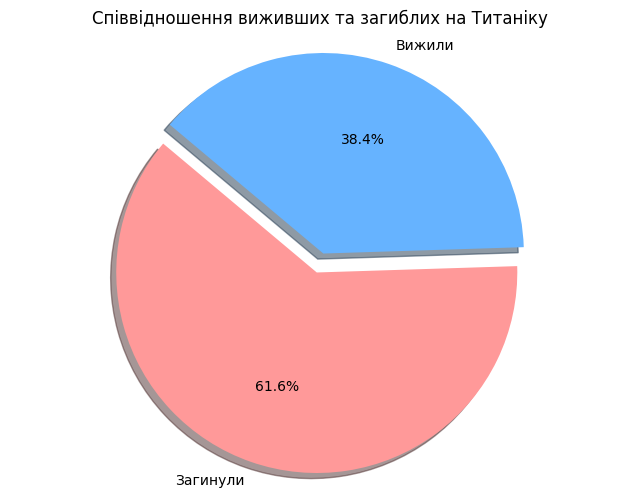

In [14]:

survival_counts = data['Survived'].value_counts()

labels = ['Загинули', 'Вижили']
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)

plt.figure(figsize=(8, 6))
plt.pie(survival_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,
        shadow=True)

plt.title('Співвідношення виживших та загиблих на Титаніку')
plt.axis('equal')
plt.show()

*прокоментуйте отримані візуалізації

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


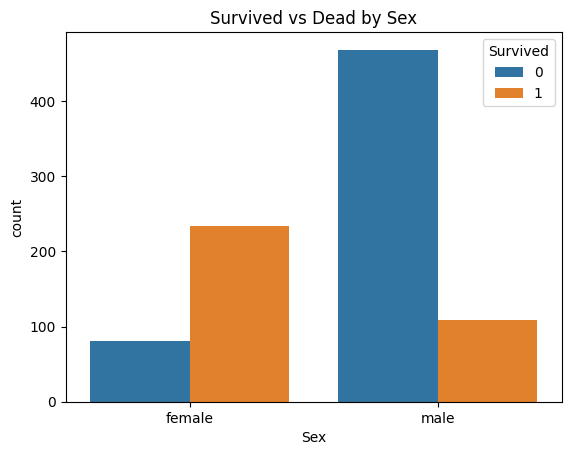

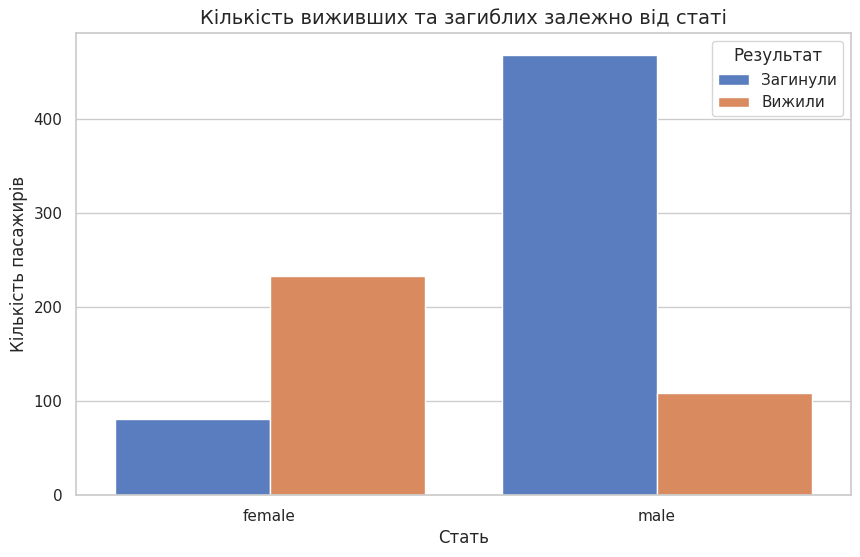

In [22]:
survival_by_sex = data.groupby(['Sex', 'Survived'], as_index=False).size()

survival_by_sex = survival_by_sex.rename(columns={'size': 'Count'})

survival_by_sex['Status'] = survival_by_sex['Survived'].map({0: 'Загинули', 1: 'Вижили'})

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    data=survival_by_sex,
    x='Sex',
    y='Count',
    hue='Status',
    palette='muted'
)

plt.title('Кількість виживших та загиблих залежно від статі', fontsize=14)
plt.xlabel('Стать', fontsize=12)
plt.ylabel('Кількість пасажирів', fontsize=12)
plt.legend(title='Результат')

plt.show()

*прокоментуйте отримані візуалізації

4. (20б) Відобразіть кількість пропущених значень в

датасеті по кожній із змінних.

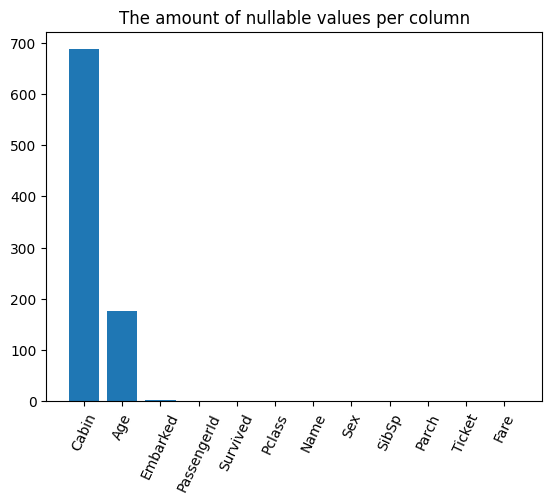

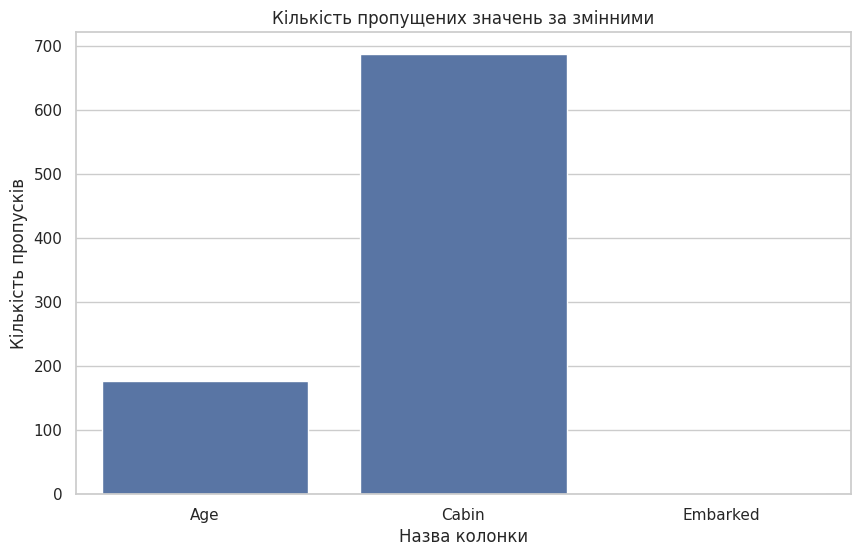

In [24]:
missing_values = data.isnull().sum()
missing_only = missing_values[missing_values > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_only.index, y=missing_only.values)

plt.title('Кількість пропущених значень за змінними')
plt.ylabel('Кількість пропусків')
plt.xlabel('Назва колонки')
plt.show()

*прокоментуйте отримані візуалізації

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

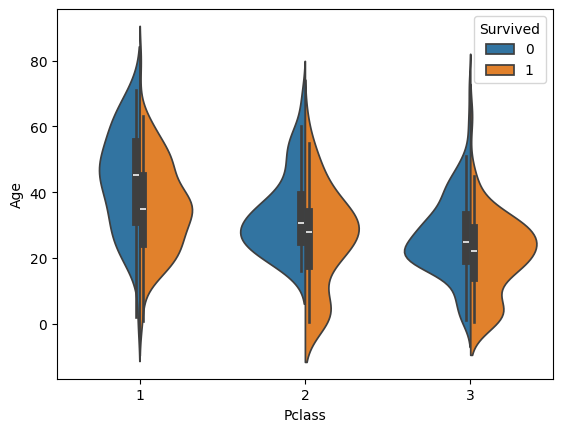

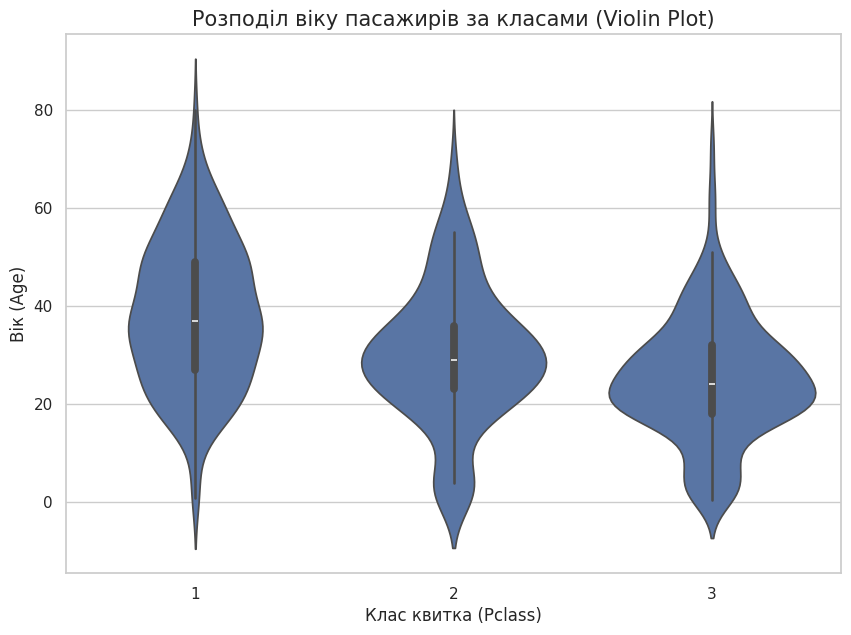

In [32]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))
sns.violinplot(x='Pclass', y='Age', data=data, inner='box')

plt.title('Розподіл віку пасажирів за класами (Violin Plot)', fontsize=15)
plt.xlabel('Клас квитка (Pclass)', fontsize=12)
plt.ylabel('Вік (Age)', fontsize=12)

plt.show()

В 1-му класі вік розподілений більш рівномірно, тоді як у 3-му класі спостерігається різке розширення серед молоді



6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


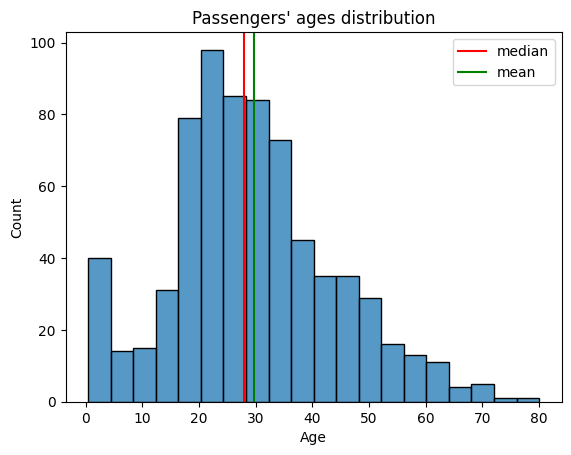

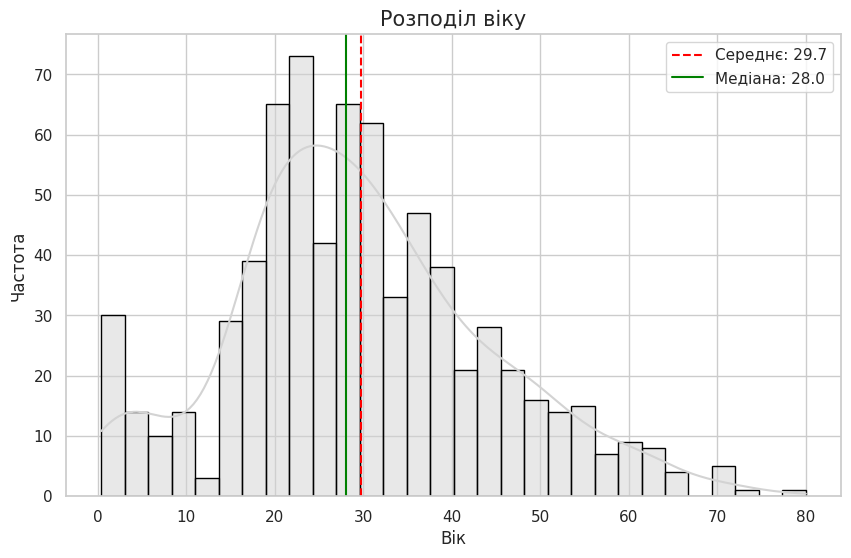

In [35]:
sns.set_theme(style="whitegrid")

age_data = data['Age'].dropna()
mean_age = age_data.mean()
median_age = age_data.median()

plt.figure(figsize=(10, 6))
sns.histplot(age_data, bins=30, kde=True, color='lightgray', edgecolor='black')

plt.axvline(mean_age, color='red', linestyle='--', label=f'Середнє: {mean_age:.1f}')
plt.axvline(median_age, color='green', linestyle='-', label=f'Медіана: {median_age:.1f}')

plt.title('Розподіл віку', fontsize=15)
plt.xlabel('Вік')
plt.ylabel('Частота')
plt.legend()

plt.show()

Більшість пасажирів були молодими людьми

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Які фактори мали найбільший вплив на шанси пасажира вижити?

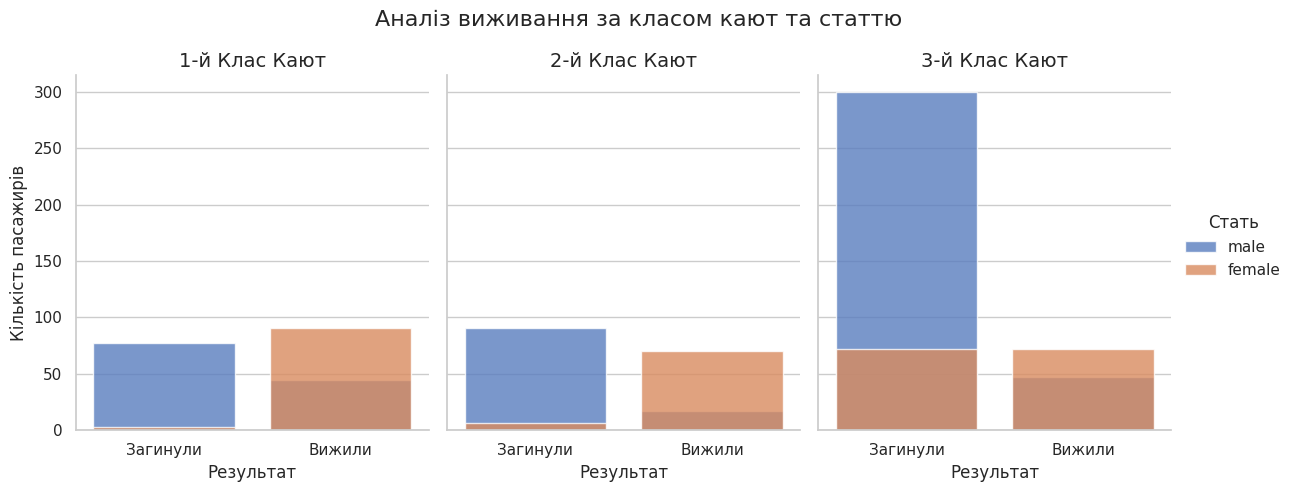

In [36]:

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(data, col="Pclass", hue="Sex", height=5, aspect=0.8, palette='muted')

g.map(sns.countplot, "Survived", order=[0, 1], alpha=0.8)

g.add_legend(title="Стать")

g.set_axis_labels("Результат", "Кількість пасажирів")
g.set_titles("{col_name}-й Клас Кают", size=14)

g.set(xticks=[0, 1], xticklabels=["Загинули", "Вижили"])

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Аналіз виживання за класом кают та статтю', fontsize=16)

plt.show()

Ключовим фактором виживання була стать (жінки мали пріоритет), але клас квитка теж суттєво вплинув на шанси вижити. Тобто жінки 1-го класу були в найбільшій безпеці, а чоловіки 3-го класу були в найбільшій небезпеці.



# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

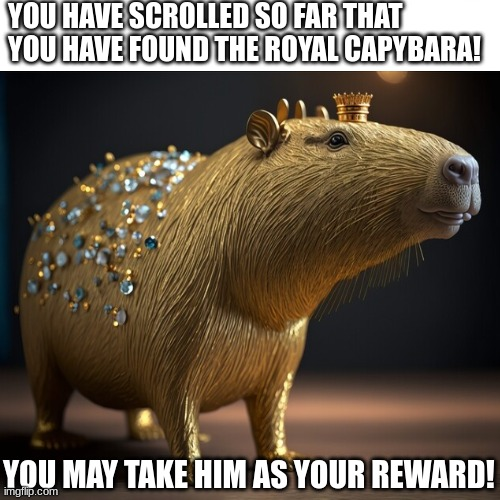